In [ ]:
import os
import sys
import time
import json
import random
import argparse
from pathlib import Path

import torch

# Repo setup
repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from argparse import Namespace
from pathlib import Path
import torch

from revlm.config_utils import configure_args
from revlm.run.edit import run_edit

editor_name = "ike"


Task evaluation metrics will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Edit evaluation metrics will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Predictions will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa
Post-edit predictions will be saved to /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa/pred_postedit
Unified filename to save: mc_all_sub500.json
Step 1 (predictions)
Total samples 500 loaded from /scratch/jq2uw/MME/instruct_vlm_edit/results/test/editor_ike_chain/qwen3_4b/aokvqa/pred_mc.json
getting edits predicted by: label_maxprob

model_old predictions:
{'uid': '820', 'image': 'data/images/aokvqa/train2017/000000202990.jpg', 'question': 'When is it safe to cross the street here?', 'answer': 'now', 'rationale': 'You can tell by the orange hand on the street sign as to if it is safe to cross.', 'c

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jq2uw/.netrc.
wandb: Currently logged in as: jq2uw (vlm_edit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Batch 1: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...
[Keys] +5 added, 7 merged (from 12 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 0->5 keys, 0.0 MB
Batch 2: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Keys] +4 added, 3 merged (from 7 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 5->9 keys, 0.0 MB
Batch 3: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...[Keys] +7 added, 0 merged (from 7 candidates)
[IKE_CHAIN] +1 edits (p_yes>0.5, merge=True, area=0.9), 9->16 keys, 0.1 MB
Batch 4: editing
[IKE_CHAIN] mode=dual_sbert, pool=mean, pair_rationale_w=both, merge=True, aug_patch=False, aug_orig=False
[IKE_CHAIN] edit 1/1...

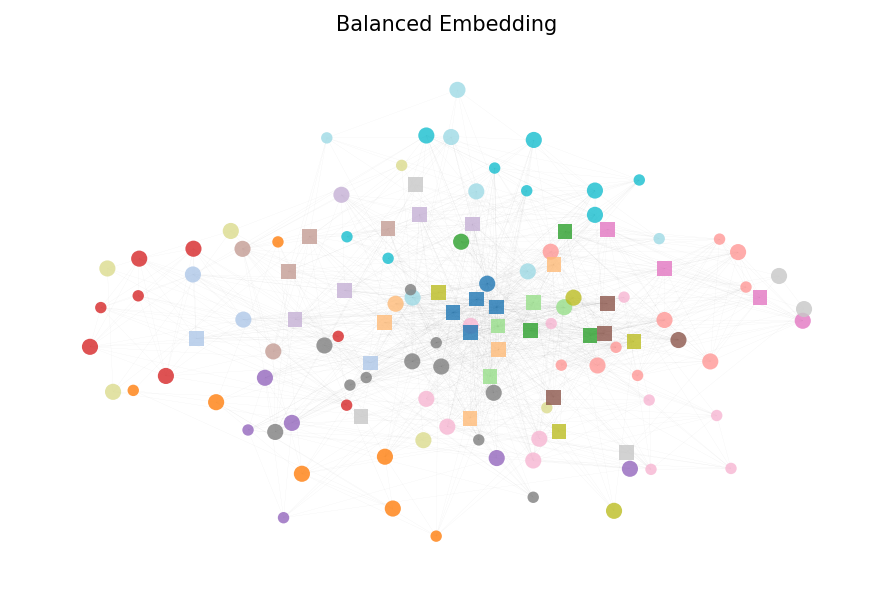

[Timing] reliability: 15.41s
Reliability: 1.0000
[IKE_CHAIN] applied facts to 100/100 examples
  [0] q='On what type of surface are the boys playing?' answer='outdoor hard' prompt='Tennis courts that are outside are often made of hard surfaces. The answer to 'What can he do with this ball?' is serve. The answer to 'What surface are the boys playing on?' is outdoor hard. The tennis court is visible in the image. The setting appears to be outdoors. The image shows two boys playing tennis. On what type of surface are the boys playing?'
  [1] q='What kind of ground are the boys playing on?' answer='outdoor hard' prompt='Tennis courts that are outside are often made of hard surfaces. The answer to 'What can he do with this ball?' is serve. The answer to 'What surface are the boys playing on?' is outdoor hard. The tennis court is visible in the image. The setting appears to be outdoors. The image shows two boys playing tennis. What kind of ground are the boys playing on?'
  [2] q='What is th

KeyboardInterrupt: 

In [ ]:

# Project root
project_root = Path(repo_root)

# Build test paths from args (no hardcoding)
args = Namespace(
    config="revlm/config/config.yaml",
    editor=editor_name,
    model_name="qwen3_4b",
    dataset_name="aokvqa",
    task="mc",
    batch_size=1,
    split="all",
    rationale=False,
    cot=False,
    subsample=500,
    subsample_edits=100,
    overwrite=True,
)

# Derive result prefix from args
res_prefix = project_root / "results" / "test" / f"editor_{args.editor}" / args.model_name / args.dataset_name
res_prefix.mkdir(parents=True, exist_ok=True)
(res_prefix / "pred_postedit").mkdir(parents=True, exist_ok=True)

# Force all outputs into the test prefix (overwrite allowed)
args.task_dir = str(res_prefix)
args.edit_dir = str(res_prefix)
args.pred_dir = str(res_prefix)
args.pred_path = str(res_prefix / f"pred_mc.json")
args.pred_postedit_dir = str(res_prefix / f"pred_postedit")

args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
args.suffix = "_cot" if args.rationale and args.cot else ("_rationale" if args.rationale else "")

config = configure_args(args, config_path=args.config)
config.subsample = args.subsample
config.subsample_edits = args.subsample_edits
config.rationale = args.rationale
config.cot = args.cot
config.pred_path = args.pred_path
config.overwrite = args.overwrite
config.task_dir = args.task_dir
config.pred_dir = args.pred_dir
config.pred_postedit_dir = args.pred_postedit_dir
config.edit_dir = args.edit_dir

config.plot_k_dist = True 
run_edit(config, sequential=True, eval_every=20)